Load models from Bradley-Terry/ModelPool

In [3]:
import os
from CatanSimulator import RunGame
import random
from DeepLearning.Thesis.Environments.DummyEnv import DummyEnv
from DeepLearning.PPO import MaskablePPO
from Agents.AgentRandom2 import AgentRandom2
from Agents.AgentUCT import AgentUCT
from Agents.AgentModel import AgentModel
from DeepLearning.Thesis.Observations.get_observation_full import getObservationFull, lowerBound, upperBound
from DeepLearning.GetActionMask import getActionMask, getActionMaskTrading

agent_list = ["Random" , "UCT50"]

def load_models_from_folder(folder_path):
    model_list = []

    for file in os.listdir(folder_path):
        full_path = os.path.join(folder_path, file)

        # 只保留文件，不要子目录
        if os.path.isfile(full_path):
            model_list.append(file)

    return model_list



ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

In [4]:
import pandas as pd
import os

def load_model_agent(model_name, seat_number, env):
    """
    根据模型名加载 agent
    """
    if model_name == "UCT50":
        return AgentUCT(name=f"P{seat_number}",
                        seatNumber=seat_number,
                        simulationCount = 50)
    if model_name == "Random":
        return AgentRandom2(name=f"P{seat_number}",
                            seatNumber=seat_number)
    """
    根据模型名加载 model
    """

    model_path = os.path.join("Bradley-Terry", "ModelPool", model_name)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")

    model = MaskablePPO.load(model_path, env = env)
    model.getActionMask = getActionMask
    model.getObservation = getObservationFull

    return AgentModel(
        name=f"P{seat_number}",
        seatNumber=seat_number,
        model=model
    )


def load_win_matrix(filename="Bradley-Terry/bt_matrix.csv"):
    # Check if file exists AND is not empty
    if os.path.exists(filename) and os.path.getsize(filename) > 0:
        try:
            df = pd.read_csv(filename, index_col=0)
            return df
        except pd.errors.EmptyDataError:
            # Fallback if getsize missed something or file is just whitespace
            print(f"Warning: {filename} is empty.")
            return pd.DataFrame()
    else:
        # If file doesn't exist or is 0 bytes, return empty DF
        return pd.DataFrame()

def ensure_model_exists(df, model_name):
    if model_name not in df.index:
        # 新模型列表
        new_models = list(df.index) + [model_name]

        # 重新构造完整方阵
        df = df.reindex(index=new_models, columns=new_models, fill_value=0)

    return df

def update_from_game(df, selected, winner_index):
    winner = selected[winner_index]

    # 先保证所有模型存在
    for model in selected:
        df = ensure_model_exists(df, model)

    # winner 胜其他人
    for model in selected:
        if model != winner:
            df.loc[winner, model] += 1

    return df

def save_win_matrix(df, filename="Bradley-Terry/bt_matrix.csv"):
    df.to_csv(filename)

Run simulation and update results to Win Matrix

In [5]:
import gc
model_list = load_models_from_folder("Bradley-Terry/ModelPool")
# print model_list

model_list = model_list + agent_list

simulate_games = 2000

win_matrix = load_win_matrix()

for i in range(simulate_games):
    selected = random.sample(model_list, 4) # 随机抽4个模型
    players = [
        load_model_agent(selected[0], 0, env = DummyEnv()),
        load_model_agent(selected[1], 1, env = DummyEnv()),
        load_model_agent(selected[2], 2, env = DummyEnv()),
        load_model_agent(selected[3], 3, env = DummyEnv()),
    ]



    winner = RunGame(players = players)
    print("Game <" + str(i) + ">: " + selected[winner] + "wins.")

    win_matrix = update_from_game(win_matrix, selected, winner)

    # 🟢 手动释放
    del players
    gc.collect()  # 强制回收

    if i % 10 == 5:
        print("win_matrix Updated!")
        save_win_matrix(win_matrix)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


D:\ProgramData\Anaconda3_\envs\catan\Lib\site-packages\stable_baselines3\common\utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <0>: model_3649018_97.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <1>: model_6211066_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <2>: model_6227450_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wra

D:\ProgramData\Anaconda3_\envs\catan\Lib\site-packages\stable_baselines3\common\utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")


Game <3>: model_6211066_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <4>: model_6215162_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


...

D:\ProgramData\Anaconda3_\envs\catan\Lib\site-packages\stable_baselines3\common\utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")


Game <27>: UCT50wins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


D:\ProgramData\Anaconda3_\envs\catan\Lib\site-packages\stable_baselines3\common\utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")


Game <28>: model_6215162_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <29>: model_6211066_93.zipwins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


KeyboardInterrupt: 

Get Bradley-Terry according to Win Matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bradley_terry_score(win_matrix, max_iter=1000, tol=1e-6, eps=1e-8):
    """
    用迭代法计算 Bradley-Terry 模型评分（避免胜率为0报错）
    win_matrix: DataFrame, 行i列j表示i胜j的次数
    eps: 避免0值的小常数
    """
    items = win_matrix.index.tolist()
    n = len(items)

    W = win_matrix.values.astype(float)

    # 初始化每个模型的能力值 pi，避免0
    p = np.ones(n) * 0.5

    for iteration in range(max_iter):
        p_old = p.copy()
        for i in range(n):
            numerator = 0
            denominator = 0
            for j in range(n):
                if i == j:
                    continue
                numerator += W[i, j] * p[j] / max(p[i] + p[j], eps)
                denominator += W[j, i] / max(p[i] + p[j], eps)
            # 避免除0
            if denominator > 0:
                p[i] = numerator / denominator
            else:
                p[i] = eps  # 如果全0就给个小值
        # 归一化，避免0
        p = np.maximum(p, eps)
        p = p / (np.prod(p) ** (1/n))
        if np.max(np.abs(p - p_old)) < tol:
            break

    # 转成 Elo 风格分数
    elo_scores = 400 * np.log10(p)
    return pd.Series(elo_scores, index=items)

# 使用示例
win_matrix = load_win_matrix()
bt_scores = bradley_terry_score(win_matrix)

bt_scores = bt_scores.clip(lower=0)

print(bt_scores)

ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

NameError: name 'load_win_matrix' is not defined

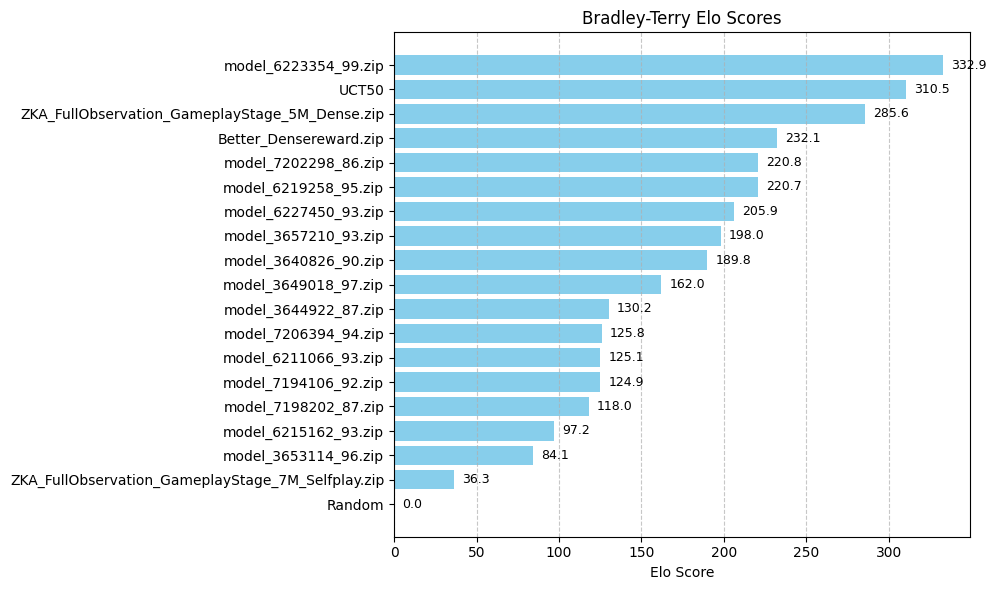

In [7]:
def plot_bt_scores(bt_scores, title="Bradley-Terry Elo Scores"):
    """
    绘制模型分数的条形图
    """
    # 按分数排序
    bt_scores_sorted = bt_scores.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(bt_scores_sorted.index, bt_scores_sorted.values, color='skyblue')

    # 显示数值
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}', va='center', fontsize=9)

    plt.xlabel("Elo Score")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_bt_scores(bt_scores)